In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from inputs_for_plots import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

In [18]:
def prepare_error_dataframe(ols_est, column_extraction ,errors_list, column_names):
    """Creates a DataFrame with all error values in a long format."""
    df_list = [pd.DataFrame(np.abs(ols_est), columns=["Biased OLS"]),
               pd.DataFrame(np.abs(column_extraction), columns=["Column extraction"])]
    
    for errors, col_name in zip(errors_list, column_names):
        df_list.append(pd.DataFrame(errors["error"], columns=[col_name]))
    return pd.concat(df_list, axis=1)




# Plot increase in confounding

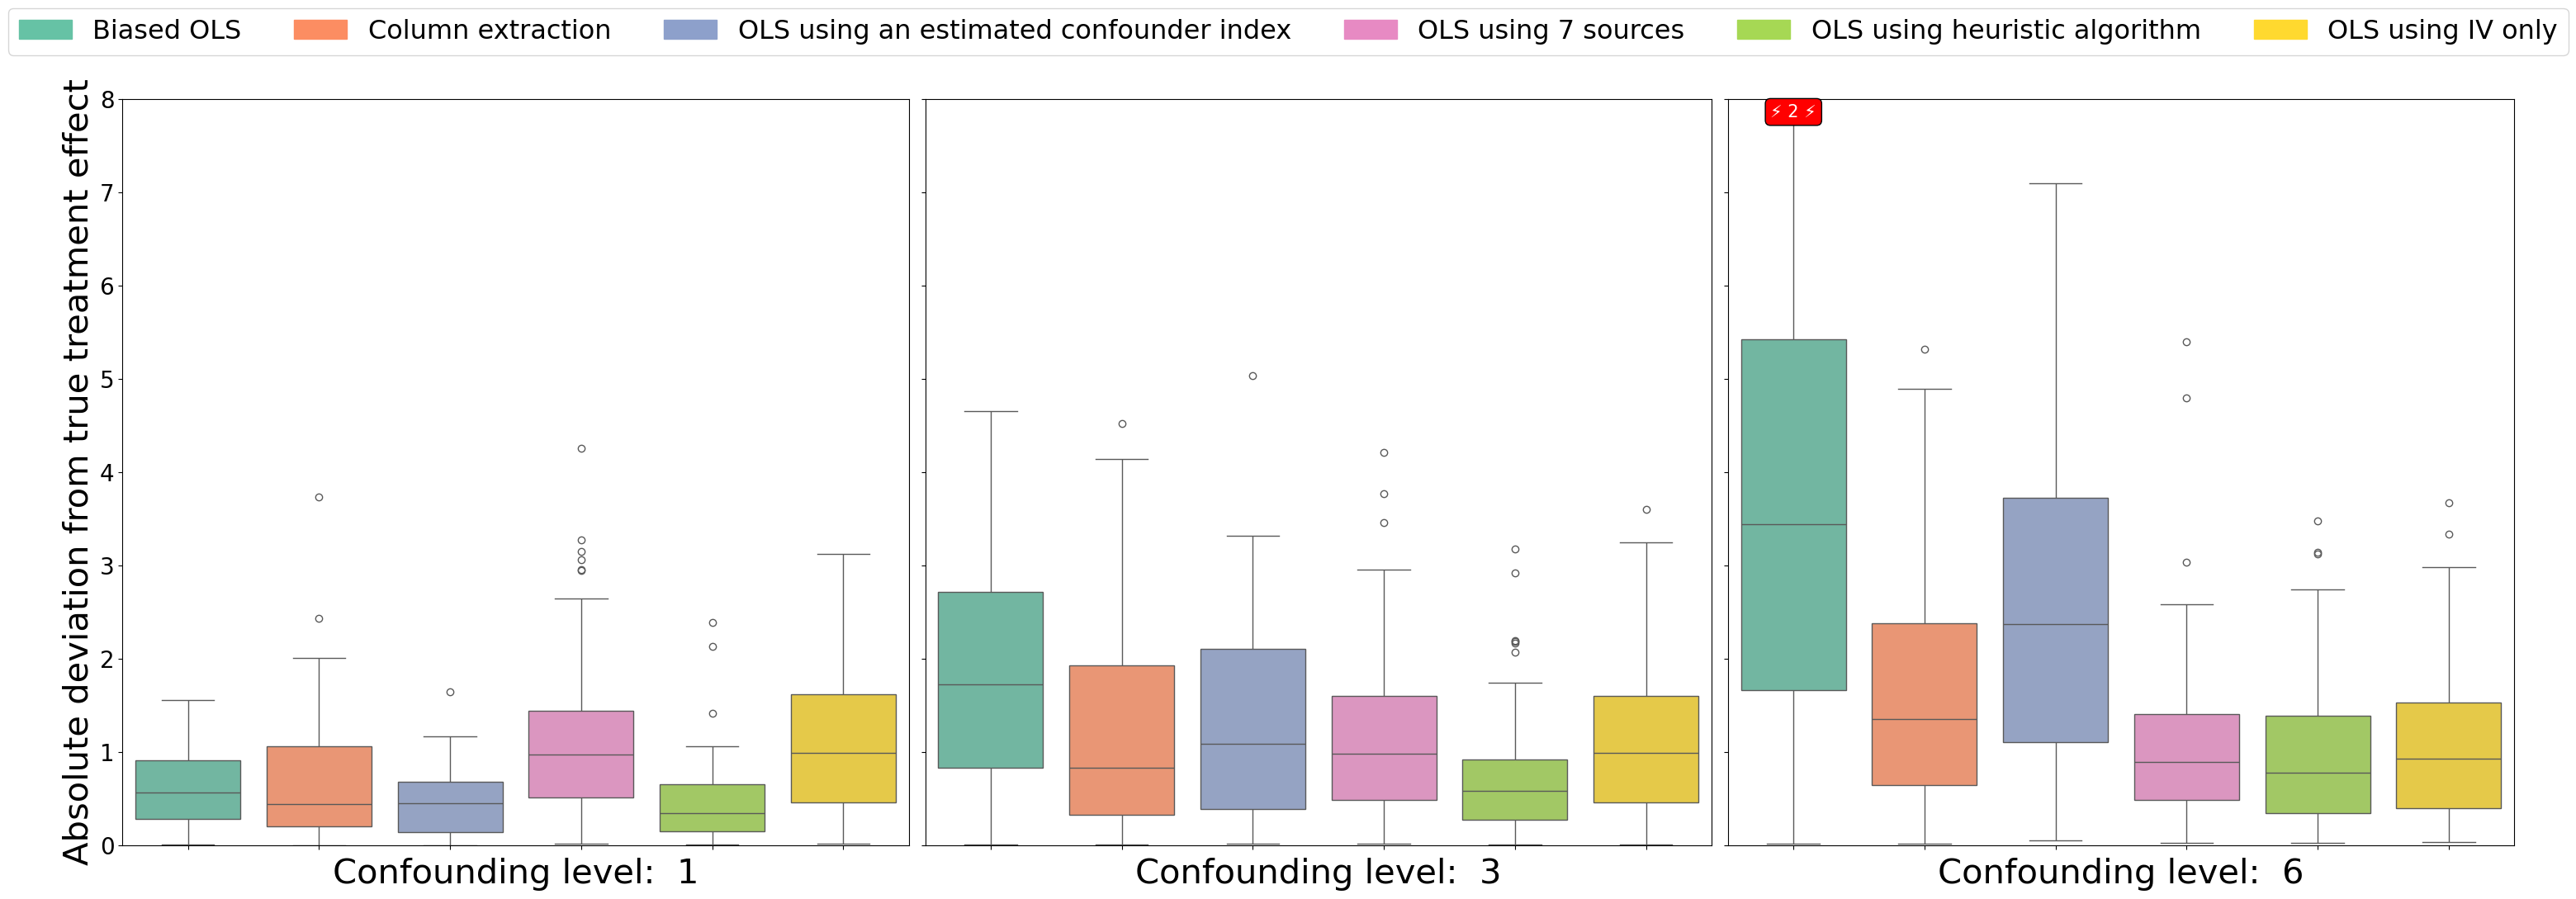

In [19]:

def main_plot(confounder_levels):
    """Generates plots for different confounder levels."""
    method_summary = {}
    fig, axes = plt.subplots(1, len(confounder_levels), figsize=(30, 10), sharey=True)
    
    for i, level in enumerate(confounder_levels):
        rmse, mae, std = [], [], []
        true_treatment_effect = get_true_treatment_effect(path=f"data_generation/different_confounding_levels/data/", name=f"true_mixing_large_conf_{level}_")
        ols_est = calculate_ols_estimate(path=f"data_generation/different_confounding_levels/data/", name=f"data_obs_large_conf_{level}_")
        ols_est = np.array(ols_est) - np.array(true_treatment_effect)
        gather_statistics({"RMSE": np.sqrt(np.mean(np.array(ols_est)**2)), "MAE": np.mean(np.abs(ols_est)), "STD": np.std(ols_est)}, rmse, mae, std)

        column_extraction_est = column_extraction(path = "data_generation/different_confounding_levels/data/", name  = f"estimated_mixing_CausalVarEM_large_conf_{level}")
        column_extraction_est = np.array(column_extraction_est) - np.array(true_treatment_effect)
        gather_statistics({"RMSE": np.sqrt(np.mean(np.array(column_extraction_est)**2)), "MAE": np.mean(np.abs(column_extraction_est)), "STD": np.std(column_extraction_est)}, rmse, mae, std)

        errors_confounder = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_confounder_source_cn_{level}.csv", "estimated_treatment_using_confounder_source", "true_treatment_effect")
        gather_statistics(errors_confounder, rmse, mae, std)
        
        errors_7_sources = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_7_sources_cn_{level}.csv", "estimated_treatment_on_sources", "true_treatment_effect")
        gather_statistics(errors_7_sources, rmse, mae, std)
        
        errors_nonsense = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_7_sources_nonsense_cn_{level}.csv", "mistaken_scheme", "true_treatment_effect")
        gather_statistics(errors_nonsense, rmse, mae, std)

        errors_iv_only = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_iv_only_cn_{level}.csv", "iv_only_effect", "true_treatment_effect")
        gather_statistics(errors_iv_only, rmse, mae, std)
        
        err = prepare_error_dataframe(ols_est, column_extraction_est, [errors_confounder, errors_7_sources, errors_nonsense, errors_iv_only], ["OLS using an estimated confounder index", "OLS using 7 sources", "OLS using heuristic algorithm", "OLS using IV only"])
        
        cases = {col: 100 - err[col].isna().sum() for col in err.columns}
        method_summary[level] =  {"cases": cases,"rmse": rmse, "mae": mae, "std": std}
        palette = plot_errors(err, rmse, mae, std, axes[i], level, "Confounding level")
    
    # add one legend for all plots
    add_one_legend(fig, err, palette)
    plt.tight_layout()
    plt.show()
    return method_summary



# Example usage
confounder_levels = [1, 3, 6]
method_summary = main_plot(confounder_levels)
# print method summary as a table


In [20]:
print_method_summary(method_summary)

Level 1
       Biased OLS  Column extraction  OLS using an estimated confounder index  \
RMSE     0.688614           0.922881                                 0.595175   
MAE      0.585996           0.674720                                 0.473394   
STD      0.687864           0.921088                                 0.590949   
Cases  100.000000         100.000000                                76.000000   

       OLS using 7 sources  OLS using heuristic algorithm  OLS using IV only  
RMSE              1.376951                       0.613627           1.349548  
MAE               1.101847                       0.447374           1.106903  
STD               1.357780                       0.609622           1.345847  
Cases            95.000000                      84.000000          86.000000  
Level 3
       Biased OLS  Column extraction  OLS using an estimated confounder index  \
RMSE     2.060265           1.578265                                 1.708286   
MAE      1.753669    

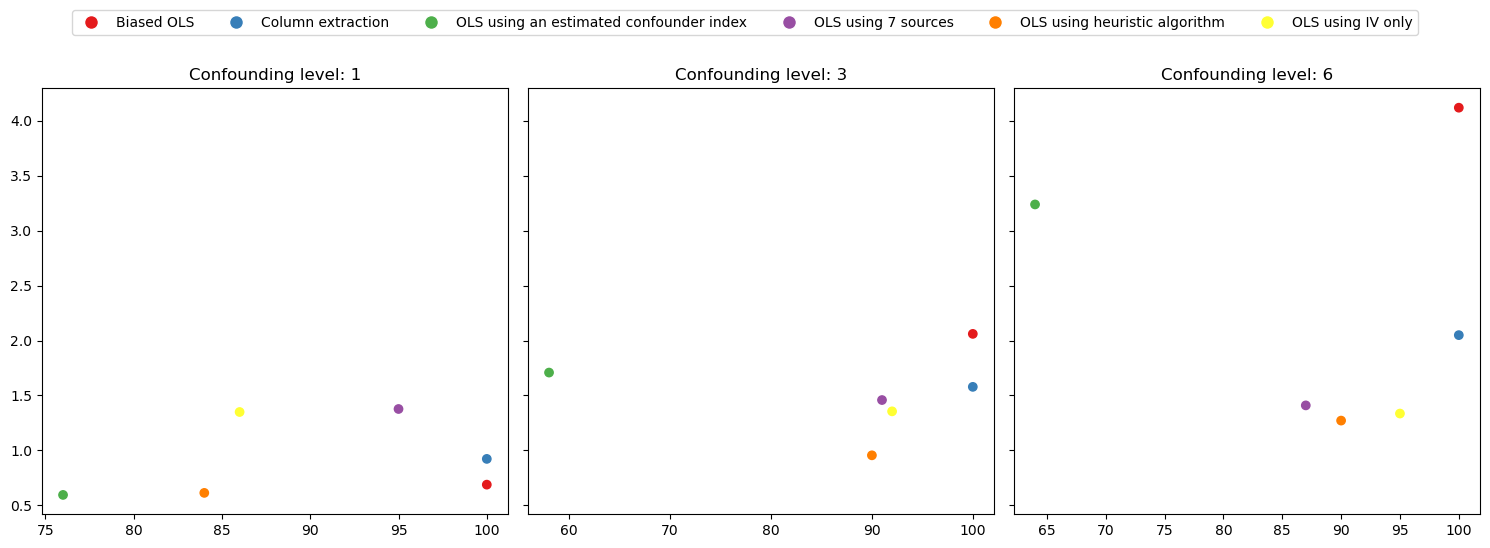

In [21]:
plot_cases_vs_performance(method_summary, "rmse", "Confounding level")

 # Plot bounded treatment effect

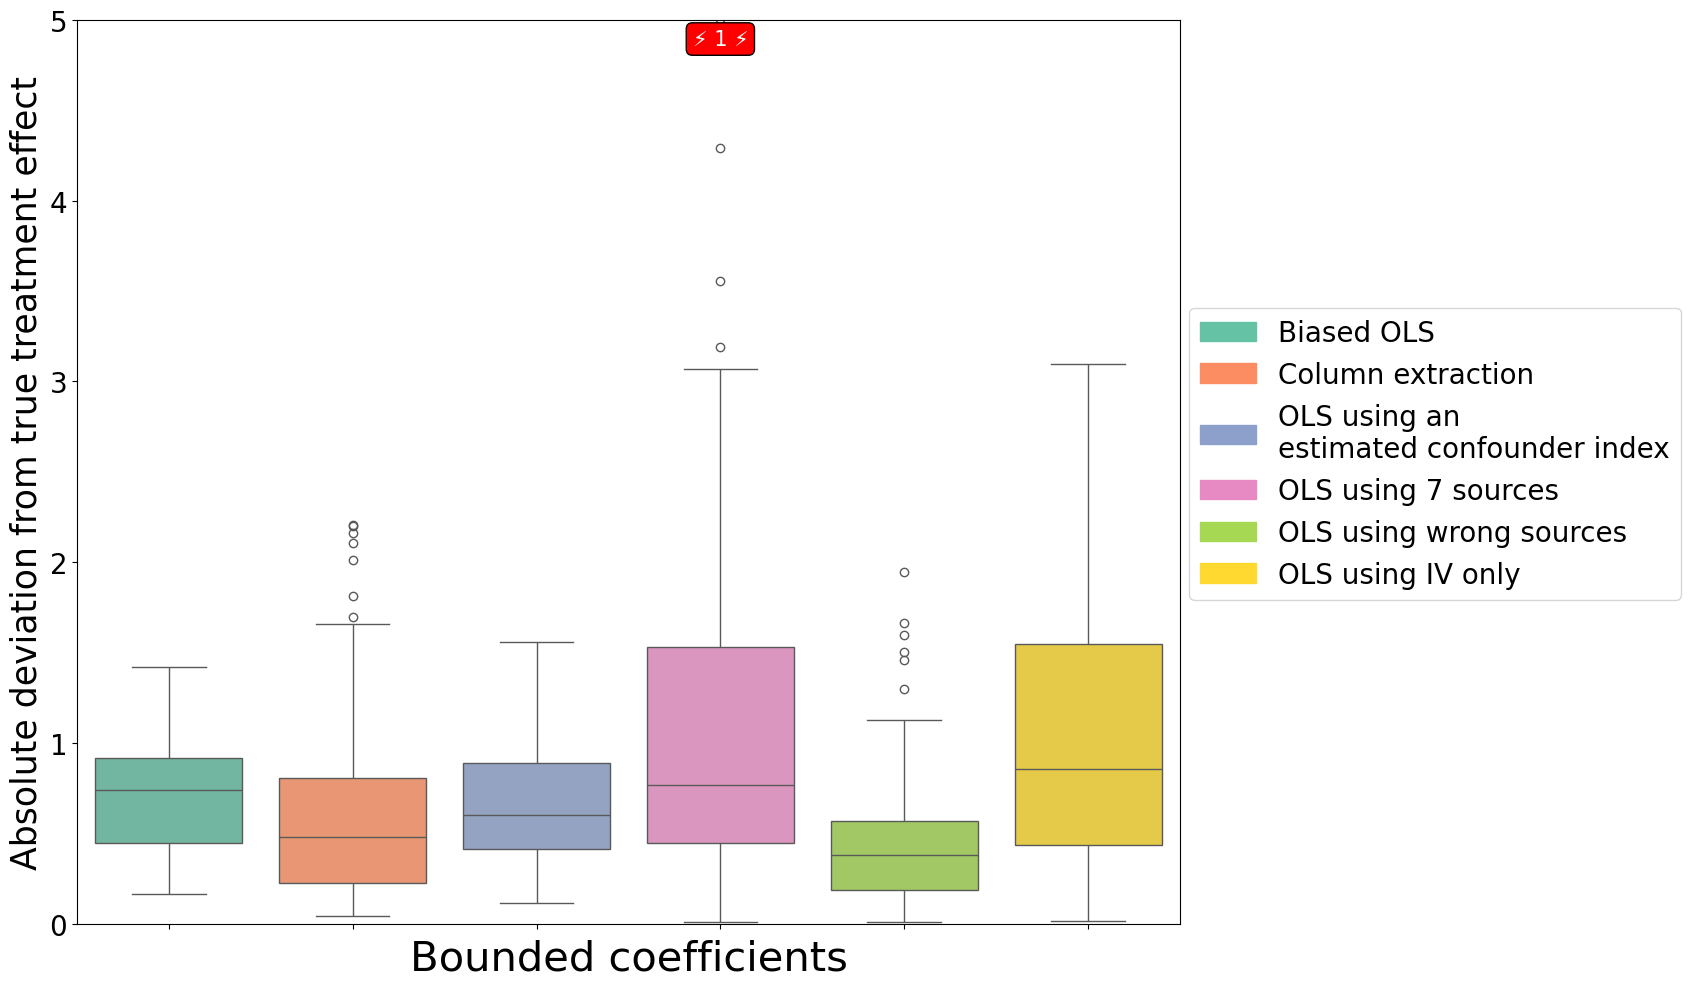

Bounded treatment effect
                                               RMSE       MAE       STD
Biased OLS                                 0.779054  0.713521  0.777512
Column extraction                          0.837573  0.633105  0.834212
OLS using an \nestimated confounder index  0.718761  0.643209  0.711011
OLS using 7 sources                        1.405930  1.068531  1.397806
OLS using wrong sources                    0.624218  0.466707  0.621061
OLS using IV only                          1.284055  1.032078  1.262986


In [25]:
def plot_errors_bounded(err, rmse, mae, std,ax, y_lim = 5):
    """Creates boxplots and adds legend with RMSE, MAE, and STD."""
    df_long = err.melt(var_name="variable", value_name="value").dropna()
    palette = sns.color_palette("Set2", n_colors=len(df_long["variable"].unique()))
    boxplot = sns.boxplot(data=df_long, y="value", x="variable", hue="variable", ax=ax, palette=palette, legend=False)
    
    ax.set_xlabel(f"Bounded coefficients", fontsize=30)
    ax.set_ylabel("Absolute deviation from true treatment effect", fontsize=25)

    ax.set_xticklabels([])  
    ax.tick_params(axis='both', which='major', labelsize=20)

    ax.set_ylim((0, y_lim))


    outlier_counts = df_long[df_long["value"] > y_lim].groupby("variable").size()


    positions = ax.get_xticks()  
    for pos, variable in zip(positions, df_long['variable'].unique()):
        count = outlier_counts.get(variable, 0)  
        

        if count > 0:

            ax.text(
                pos, y_lim -.05, f"⚡ {count} ⚡", 
                ha='center', va='top', 
                fontsize=15, color="white", 
                bbox=dict(facecolor='red', edgecolor='black', boxstyle='round,pad=0.3')
            )
            
    return palette


true_treatment = get_true_treatment_effect(path="data_generation/bounded_treatment_effect/data/", name="true_mixing_init_flipp_")
ols_est = calculate_ols_estimate(path=f"data_generation/bounded_treatment_effect/data/", name= "data_obs_init_flipp_")
ols_est = np.array(ols_est) - np.array(true_treatment)

column_extraction_est = column_extraction(path = "data_generation/bounded_treatment_effect/data/", name  = "estimated_mixing_CausalVarEM_init_flipp")
column_extraction_est = np.array(column_extraction_est) - np.array(true_treatment)



errors_confounder = load_and_calculate_errors("../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_confounder_source_bounded_treatment.csv", "estimated_treatment_using_confounder_source", "true_treatment_effect")
errors_7_sources = load_and_calculate_errors("../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_7_sources_bounded_treatment.csv", "estimated_treatment_on_sources", "true_treatment_effect")
errors_nonsense = load_and_calculate_errors("../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_7_sources_nonsense_bounded_treatment.csv", "mistaken_scheme", "true_treatment_effect")
errors_iv_only = load_and_calculate_errors("../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_iv_only_bounded.csv", "iv_only_effect", "true_treatment_effect")

rmse, mae, std = [], [], []
gather_statistics({"RMSE": np.sqrt(np.mean(np.array(ols_est)**2)), "MAE": np.mean(np.abs(ols_est)), "STD": np.std(ols_est)}, rmse, mae, std)
gather_statistics({"RMSE": np.sqrt(np.mean(np.array(column_extraction_est)**2)), "MAE": np.mean(np.abs(column_extraction_est)), "STD": np.std(column_extraction_est)}, rmse, mae, std)
gather_statistics(errors_confounder, rmse, mae, std)
gather_statistics(errors_7_sources, rmse, mae, std)
gather_statistics(errors_nonsense, rmse, mae, std)
gather_statistics(errors_iv_only, rmse, mae, std)

err = prepare_error_dataframe(ols_est, column_extraction_est, [errors_confounder, errors_7_sources, errors_nonsense, errors_iv_only], ["OLS using an \nestimated confounder index", "OLS using 7 sources", "OLS using wrong sources", "OLS using IV only"])
no_of_cases = {col: 100 - err[col].isna().sum() for col in err.columns}

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
palette = plot_errors_bounded(err, rmse, mae, std, ax) 
handles = [
        mpatches.Patch(color=palette[i], label=f"{err.columns[i]}")
        for i in range(len(err.columns))
    ]
    
fig.legend(handles=handles, loc="upper center", ncol=1, fontsize=20, bbox_to_anchor=(1.20, .7))
plt.tight_layout()
plt.show()

# print metric summary
print("Bounded treatment effect")
print(pd.DataFrame({"RMSE": rmse, "MAE": mae, "STD": std}, index=err.columns))

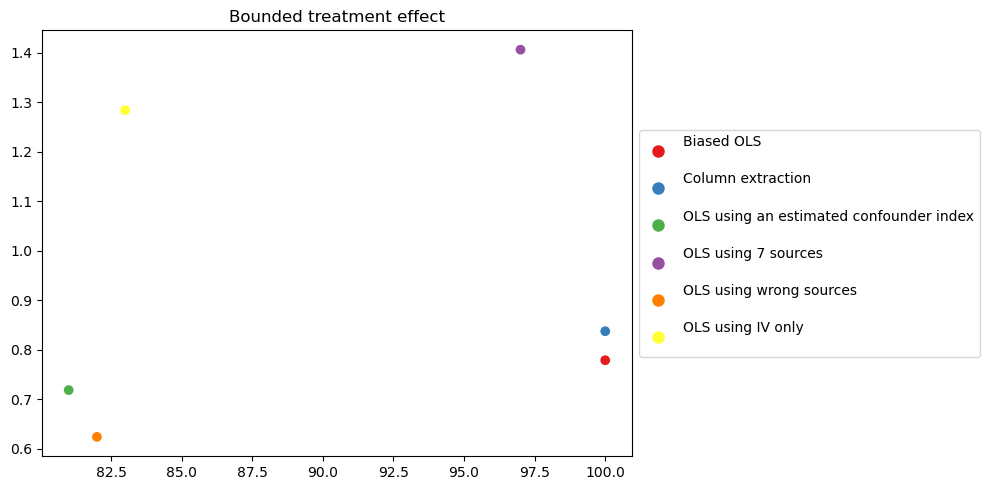

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5), sharey=True)

palette = sns.color_palette("Set1", 6)

methods = no_of_cases.keys()
cases = no_of_cases.values()

ax.scatter(cases, rmse, c=palette, label=methods)

ax.set_title("Bounded treatment effect")    

legend_labels = list(methods)
legend_colors = palette[:len(legend_labels)]
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for color in legend_colors]

# Add line breaks after each method in the legend
legend_labels = [label + '\n' for label in legend_labels]

# Position the legend to the left of the plot
ax.legend(handles, legend_labels, loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)

plt.tight_layout()
plt.show()


## Plot different number of covariates

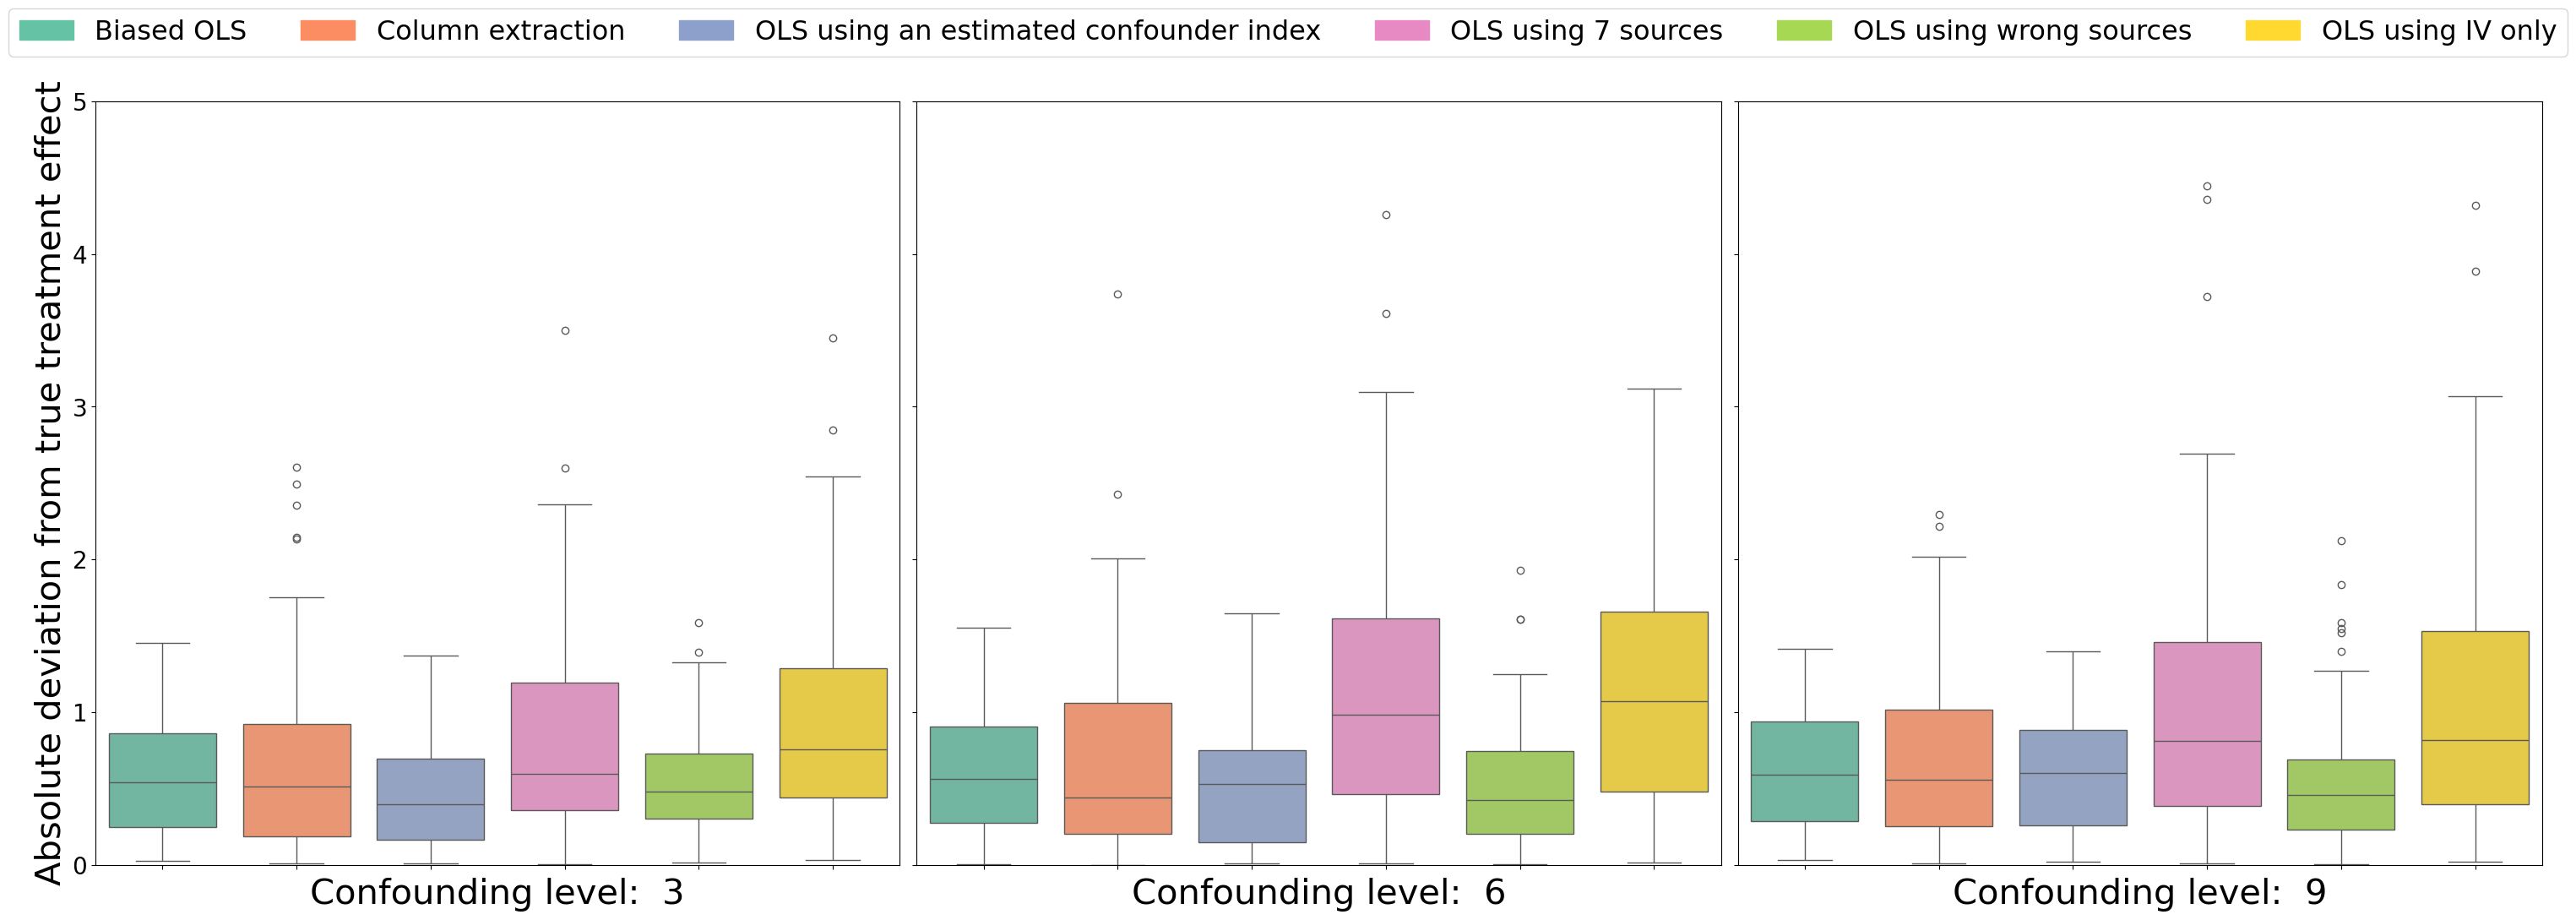

In [8]:
def main_plot(number_of_covariates):
    """Generates plots for different number of covariates."""
    method_summary = {}
    fig, axes = plt.subplots(1, len(number_of_covariates), figsize=(30, 10), sharey=True)
    
    for i, covs in enumerate(number_of_covariates):
        rmse, mae, std = [], [], []
        true_treatment_effect = get_true_treatment_effect(path=f"data_generation/different_numbers_of_covariates/data/", name=f"true_mixing_covs_{covs}_")
        ols_est = calculate_ols_estimate(path=f"data_generation/different_numbers_of_covariates/data/", name=f"data_obs_covs_{covs}_")
        ols_est = np.array(ols_est) - np.array(true_treatment_effect)
        gather_statistics({"RMSE": np.sqrt(np.mean(np.array(ols_est)**2)), "MAE": np.mean(np.abs(ols_est)), "STD": np.std(ols_est)}, rmse, mae, std)

        column_extraction_est = column_extraction(path = "data_generation/different_numbers_of_covariates/data/", name  = f"estimated_mixing_CausalVarEM_covs_{covs}")
        column_extraction_est = np.array(column_extraction_est) - np.array(true_treatment_effect)
        gather_statistics({"RMSE": np.sqrt(np.mean(np.array(column_extraction_est)**2)), "MAE": np.mean(np.abs(column_extraction_est)), "STD": np.std(column_extraction_est)}, rmse, mae, std)

        errors_confounder = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_confounder_source_number_of_covs_{covs}.csv", "estimated_treatment_using_confounder_source", "true_treatment_effect")
        gather_statistics(errors_confounder, rmse, mae, std)
        
        errors_7_sources = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_7_sources_number_of_covs_{covs}.csv", "estimated_treatment_on_sources", "true_treatment_effect")
        gather_statistics(errors_7_sources, rmse, mae, std)
        
        errors_nonsense = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_7_sources_nonsense_number_of_covs_{covs}.csv", "mistaken_scheme", "true_treatment_effect")
        gather_statistics(errors_nonsense, rmse, mae, std)
        
        errors_iv_only = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_iv_only_number_of_covs_{covs}.csv", "iv_only_effect", "true_treatment_effect")
        gather_statistics(errors_iv_only, rmse, mae, std)

        
        
        err = prepare_error_dataframe(ols_est, column_extraction_est, [errors_confounder, errors_7_sources, errors_nonsense, errors_iv_only], ["OLS using an estimated confounder index", "OLS using 7 sources", "OLS using wrong sources", "OLS using IV only"])
        
        cases = {col: 100 - err[col].isna().sum() for col in err.columns}
        method_summary[covs] =  {"cases": cases,"rmse": rmse, "mae": mae, "std": std}
        palette = plot_errors(err, rmse, mae, std, axes[i], covs, "Confounding level", y_lim=5)
    
    # add one legend for all plots
    add_one_legend(fig, err, palette)
    plt.tight_layout()
    plt.show()
    return method_summary
# Example usage
number_of_covariates = [3, 6, 9]
method_summary = main_plot(number_of_covariates)




In [9]:
print_method_summary(method_summary)

Level 3
       Biased OLS  Column extraction  OLS using an estimated confounder index  \
RMSE     0.694980           0.899986                                 0.592682   
MAE      0.572190           0.680046                                 0.474014   
STD      0.692949           0.886726                                 0.588437   
Cases  100.000000         100.000000                                65.000000   

       OLS using 7 sources  OLS using wrong sources  OLS using IV only  
RMSE              1.056558                 0.653320           1.177443  
MAE               0.829287                 0.542643           0.943052  
STD               1.033361                 0.650378           1.135129  
Cases            89.000000                86.000000          86.000000  
Level 6
       Biased OLS  Column extraction  OLS using an estimated confounder index  \
RMSE     0.688614           0.922881                                 0.641642   
MAE      0.585996           0.674720               

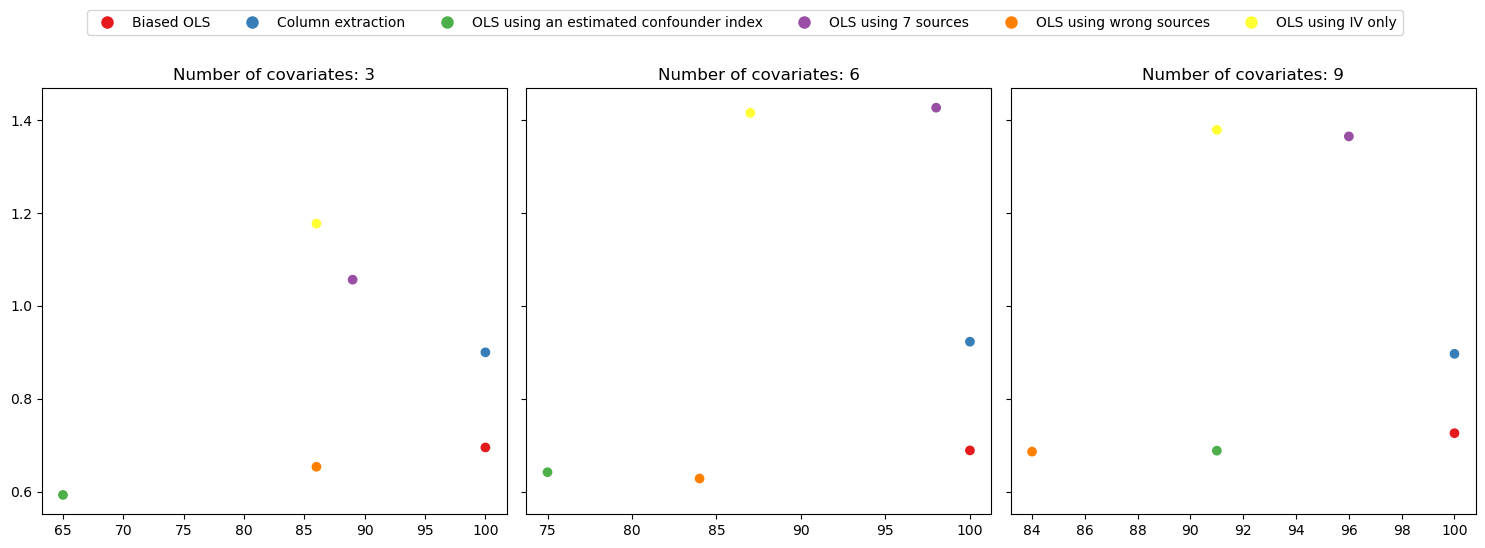

In [10]:
plot_cases_vs_performance(method_summary, "rmse", "Number of covariates")

## Sample size


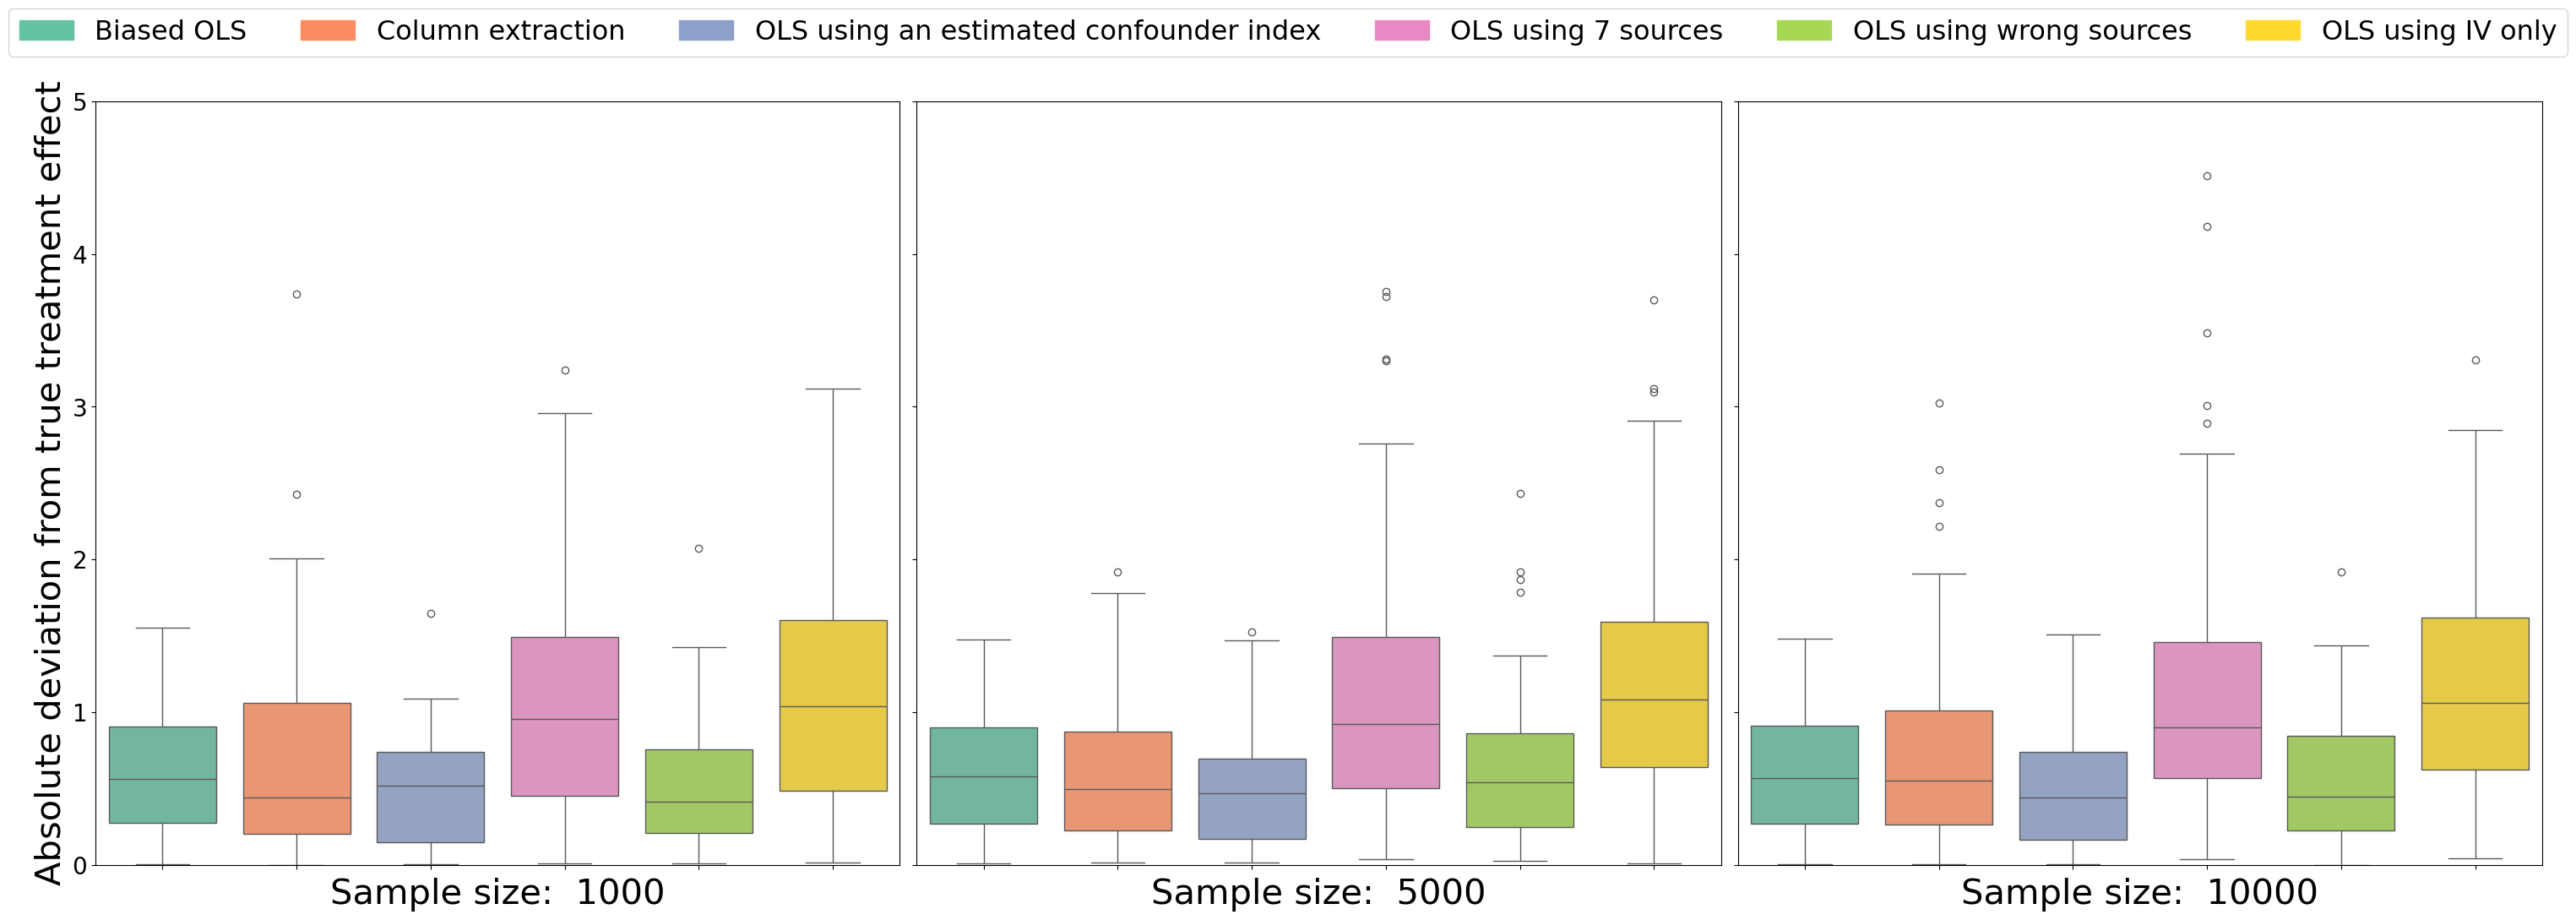

In [11]:
def main_plot(ns):
    """Generates plots for different number of covariates."""
    method_summary = {}
    fig, axes = plt.subplots(1, len(ns), figsize=(30, 10), sharey=True)
    
    for i, n in enumerate(ns):
        rmse, mae, std = [], [], []
        true_treatment_effect = get_true_treatment_effect(path=f"data_generation/differen_sample_sizes/data/", name=f"true_mixing_n:{n}_")
        ols_est = calculate_ols_estimate(path=f"data_generation/differen_sample_sizes/data/", name=f"data_obs_n:{n}_")
        ols_est = np.array(ols_est) - np.array(true_treatment_effect)
        gather_statistics({"RMSE": np.sqrt(np.mean(np.array(ols_est)**2)), "MAE": np.mean(np.abs(ols_est)), "STD": np.std(ols_est)}, rmse, mae, std)

        column_extraction_est = column_extraction(path = "data_generation/differen_sample_sizes/data/", name  = f"estimated_mixing_CausalVarEM_n:{n}")
        column_extraction_est = np.array(column_extraction_est) - np.array(true_treatment_effect)
        gather_statistics({"RMSE": np.sqrt(np.mean(np.array(column_extraction_est)**2)), "MAE": np.mean(np.abs(column_extraction_est)), "STD": np.std(column_extraction_est)}, rmse, mae, std)

        errors_confounder = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_confounder_source_n:{n}.csv", "estimated_treatment_using_confounder_source", "true_treatment_effect")
        gather_statistics(errors_confounder, rmse, mae, std)
        
        errors_7_sources = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_7_sources_n:{n}.csv", "estimated_treatment_on_sources", "true_treatment_effect")
        gather_statistics(errors_7_sources, rmse, mae, std)
        
        errors_nonsense = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_7_sources_nonsense_n:{n}.csv", "mistaken_scheme", "true_treatment_effect")
        gather_statistics(errors_nonsense, rmse, mae, std)

        errors_iv_only = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_iv_only_n:{n}.csv", "iv_only_effect", "true_treatment_effect")
        gather_statistics(errors_iv_only, rmse, mae, std)
        
        
        err = prepare_error_dataframe(ols_est, column_extraction_est, [errors_confounder, errors_7_sources, errors_nonsense, errors_iv_only], ["OLS using an estimated confounder index", "OLS using 7 sources", "OLS using wrong sources", "OLS using IV only"])
        
        cases = {col: 100 - err[col].isna().sum() for col in err.columns}
        method_summary[n] =  {"cases": cases,"rmse": rmse, "mae": mae, "std": std}
        palette =plot_errors(err, rmse, mae, std, axes[i], n, "Sample size", y_lim=5)

    add_one_legend(fig, err, palette)   
    plt.tight_layout()
    plt.show()
    return method_summary

# Example usage
ns = [1000, 5000, 10000]
method_summary = main_plot(ns)


In [12]:
print_method_summary(method_summary)

Level 1000
       Biased OLS  Column extraction  OLS using an estimated confounder index  \
RMSE     0.688614           0.922881                                 0.623532   
MAE      0.585996           0.674720                                 0.503053   
STD      0.687864           0.921088                                 0.619723   
Cases  100.000000         100.000000                                74.000000   

       OLS using 7 sources  OLS using wrong sources  OLS using IV only  
RMSE              1.288739                 0.650628           1.347846  
MAE               1.052006                 0.517984           1.121672  
STD               1.275339                 0.627478           1.344736  
Cases            95.000000                81.000000          88.000000  
Level 5000
       Biased OLS  Column extraction  OLS using an estimated confounder index  \
RMSE     0.692705           0.758405                                 0.632016   
MAE      0.587399           0.602975         

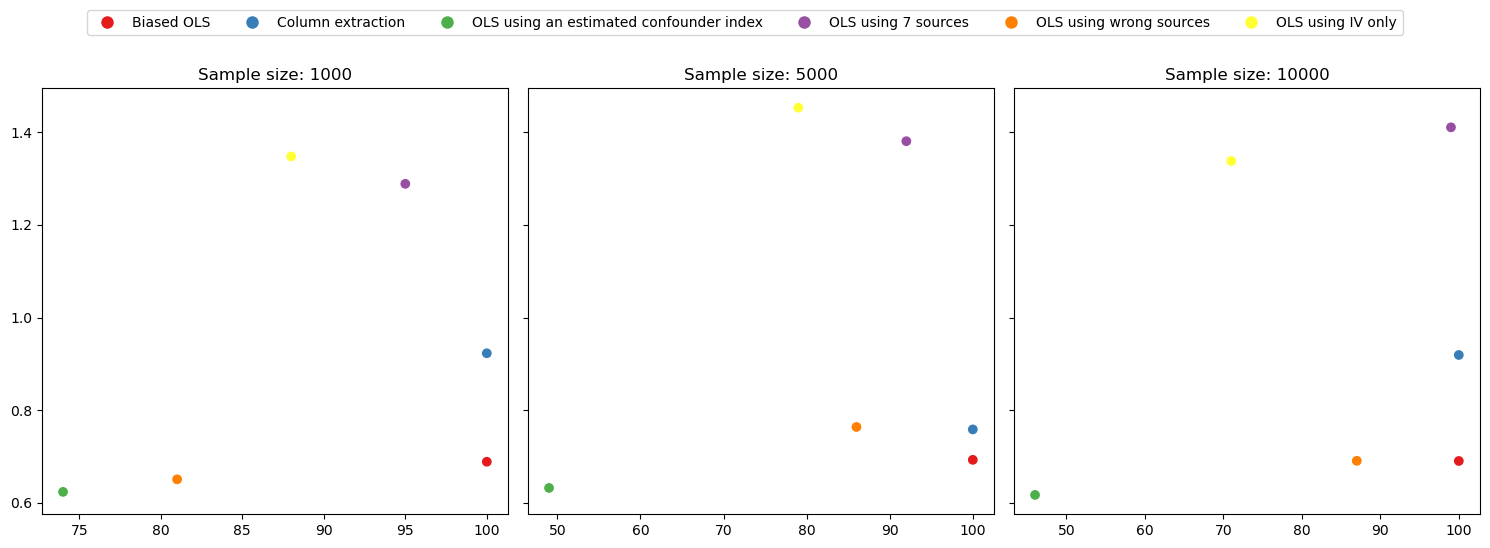

In [13]:
plot_cases_vs_performance(method_summary, "rmse", "Sample size")

# f score for different confounding levels

In [14]:
import itertools
import scipy as sp
from tqdm import tqdm
from metrics import *

In [15]:
fscores = pd.DataFrame(columns = ["cn1", "cn3", "cn6"])
scores_signals = pd.DataFrame(columns = ["cn1", "cn3", "cn6"])
scores_signals_best_perm = pd.DataFrame(columns = ["cn1", "cn3", "cn6"])
confounder_levels = [1, 3, 6]
for cn in confounder_levels:
    for i in tqdm(range(100)):
        est_signals = pd.read_csv(f"../data_generation/different_confounding_levels/data/estimated_signals_CausalVarEM_large_conf_{cn}_{i}.csv", header = 0, index_col=0)
        true_signals = pd.read_csv(f"../data_generation/different_confounding_levels/data/true_signals_large_conf_{cn}_{i}.csv", header = 0, index_col=0)
        true = pd.read_csv(f"../data_generation/different_confounding_levels/data/true_mixing_large_conf_{cn}_{i}.csv", header = 0, index_col=0)
        hat = pd.read_csv(f"../data_generation/different_confounding_levels/data/estimated_mixing_CausalVarEM_large_conf_{cn}_{i}.csv", header = 0, index_col=0)
        scores_signals.loc[i, f"cn{cn}"] = mean_squared_error(true_signals.values, est_signals.values)
        perm, score = f_score(true.values, hat.values)
        fscores.loc[i, f"cn{cn}"] = score
        scores_signals_best_perm.loc[i, f"cn{cn}"] = mean_squared_error(true_signals.values, est_signals.values[:, perm])
fscores.mean()
scores_signals.mean()
scores_signals_best_perm.mean()


100%|██████████| 100/100 [00:17<00:00,  5.87it/s]


cn1     0.88789
cn3    0.962901
cn6    1.054137
dtype: object

Text(0.5, 1.0, 'MSE of signal estimation with best permutation')

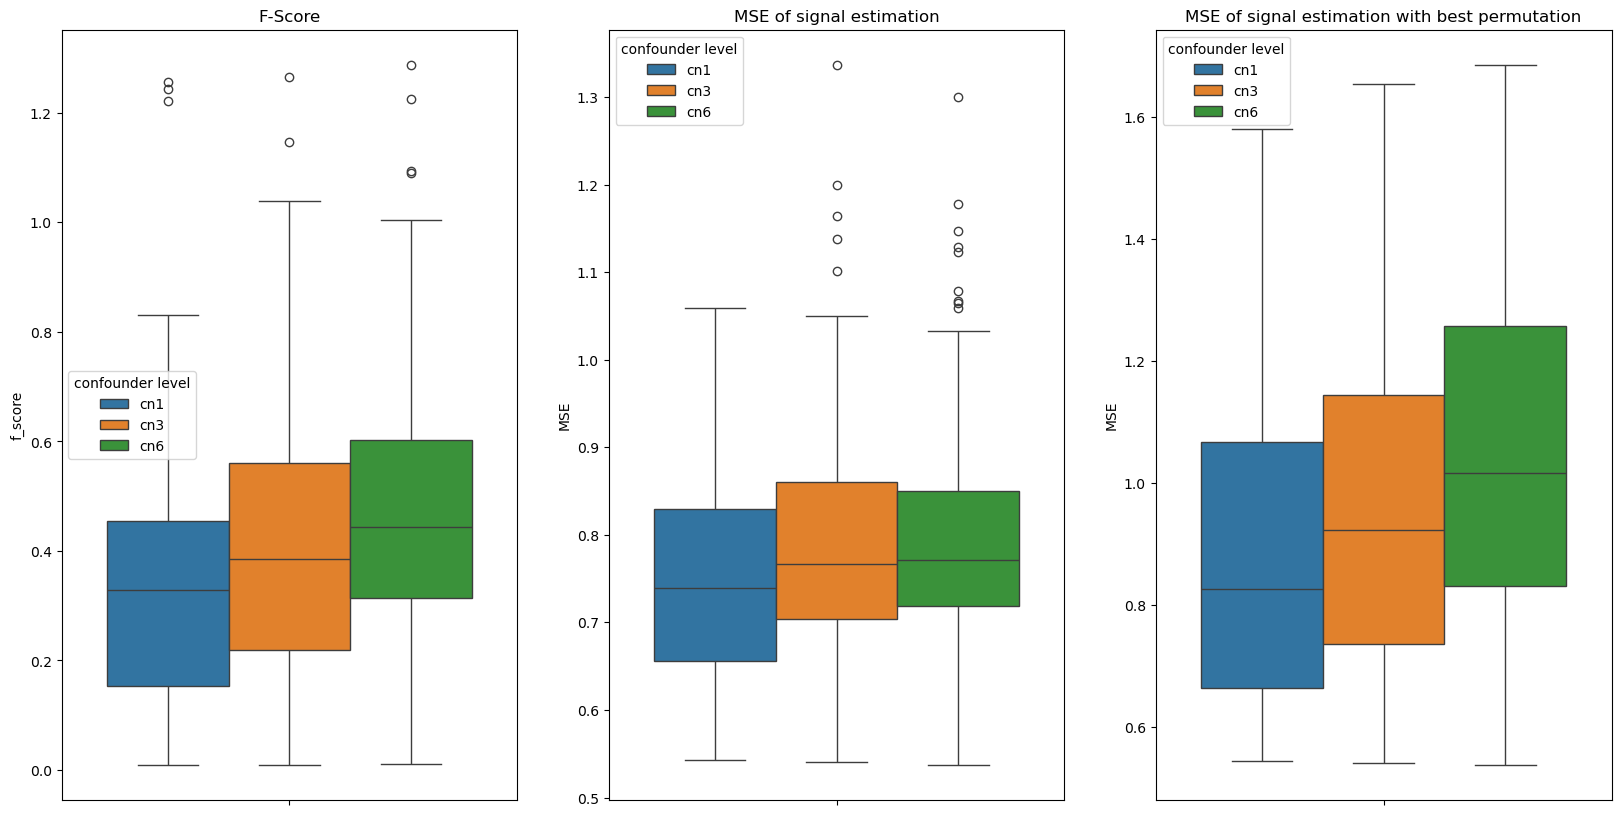

In [16]:
# plot the f_scores in one plot
fig, ax = plt.subplots(1, 3, figsize=(20, 10))
long = fscores.melt(var_name="confounder level", value_name="f_score")
sns.boxplot(data=long, hue="confounder level", y="f_score", ax=ax[0])
ax[0].set_title("F-Score")

long = scores_signals.melt(var_name="confounder level", value_name="MSE")
sns.boxplot(data=long, hue="confounder level", y="MSE", ax=ax[1])
ax[1].set_title("MSE of signal estimation")

long = scores_signals_best_perm.melt(var_name="confounder level", value_name="MSE")
sns.boxplot(data=long, hue="confounder level", y="MSE", ax=ax[2])
ax[2].set_title("MSE of signal estimation with best permutation")

